In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data = pd.read_csv("../Data/customer_segmentation.csv")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [4]:
data.shape

(2240, 29)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df = data.copy()
df.shape

(2240, 29)

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(2216, 29)

In [10]:
df.select_dtypes(exclude='object').describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
## Converting Date from object to Datatime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [12]:
df['Dt_Customer'].dtype

dtype('<M8[ns]')

In [13]:
## Creating new feature Age
df['Age'] = 2026 - df['Year_Birth']

In [14]:
## Creating new feature as Total no. of Childreans
df['Total_Childrens'] = df['Kidhome'] + df['Teenhome']

In [15]:
## Creating new feature as Total Spending
df['Total_Spending'] = df[['MntWines', 'MntFruits',
                           'MntMeatProducts', 'MntFishProducts', 
                           'MntSweetProducts','MntGoldProds']].sum(axis=1)

In [16]:
## Creating new feature for Customer Tenure
df['Customer_Since'] = (pd.Timestamp('2026-09-09') - df['Dt_Customer']).dt.days

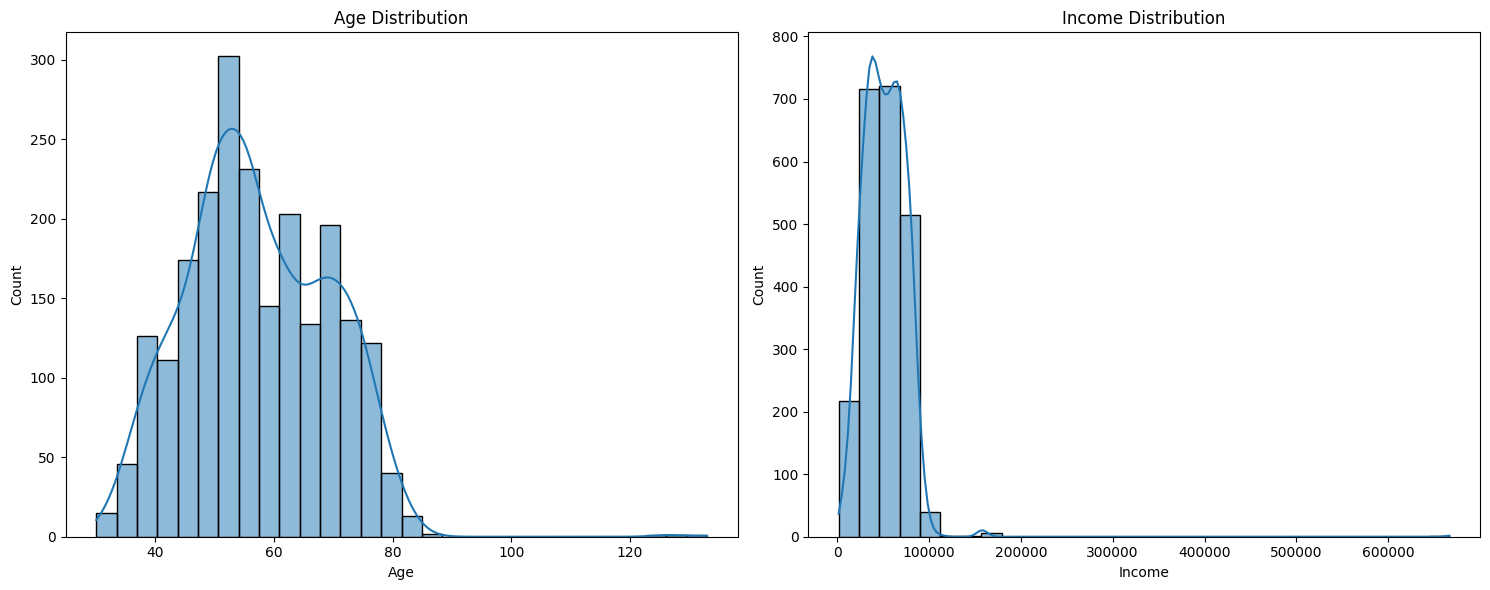

In [17]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Age Distribution")

sns.histplot(df['Income'], bins=30, kde=True, ax=ax[1])
ax[1].set_title("Income Distribution")

plt.tight_layout()
plt.show()

In [18]:
print('Skewness:')
print(f"Age: {df['Age'].skew() :.4f}")
print(f"Income: {df['Income'].skew() :.4f}")

Skewness:
Age: 0.3537
Income: 6.7635


- `Income` is higly rightly skewed. We should apply log(1+x) transformation to Income. 

In [19]:
print("Variation(S.D.)")
print(f"Age: {df['Age'].std() :.4f}")
print(f"Income: {df['Income'].std() :.4f}")

Variation(S.D.)
Age: 11.9856
Income: 25173.0767


In [20]:
df[(df['Age'] >= 40) & (df['Age'] <= 60)].shape

(1221, 33)

In [21]:
(1221/2216)*100

55.099277978339344

- **55%** of customers are from age group **40-60** years old. We can create a new feature **AgeGroup** based on this.

In [22]:
print("Age-Group Distribution")
print(f"<40: {(df[df['Age'] < 40].shape[0] / df.shape[0])*100 :.4f}")
print(f"40-60: {(df[(df['Age'] >= 40) & (df['Age'] <= 60)].shape[0] / df.shape[0])*100 :.4f}")
print(f">60: {(df[df['Age'] > 60].shape[0] / df.shape[0])*100 :.4f}")

Age-Group Distribution
<40: 6.5884
40-60: 55.0993
>60: 38.3123


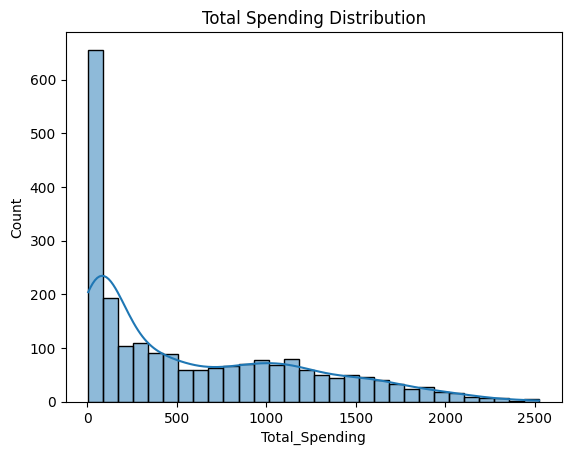

In [23]:
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

In [24]:
print(f"skewness: {df['Total_Spending'].skew():.4f}")

skewness: 0.8581


- Total spending is also hightly skewed. We need to rescale 'Total spending' to reduce skewness.

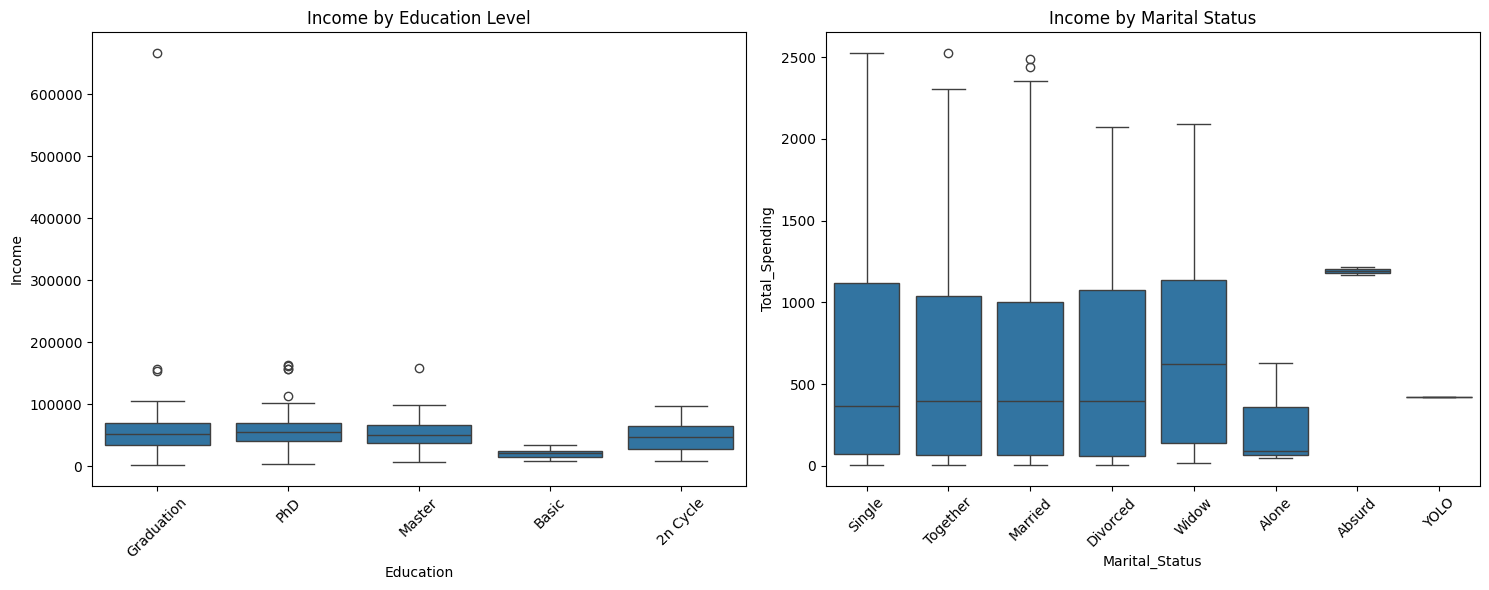

In [25]:
fig,ax = plt.subplots(1,2, figsize=(15,6))

sns.boxplot(x='Education', y='Income', data=df, ax=ax[0])
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Income by Education Level")

sns.boxplot(x='Marital_Status', y='Total_Spending', data=df, ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Income by Marital Status")

plt.tight_layout()
plt.show()

- The **income distributions of Graduate and PhD customers are relatively similar**, with a few outliers in both groups. One **extreme outlier** is also present and may indicate a potential data-entry issue that should be investigated.

- The **median income across Single, Together, Married, and Divorced customers is relatively similar**. However, some outliers are present, particularly among **Together and Married** customers.

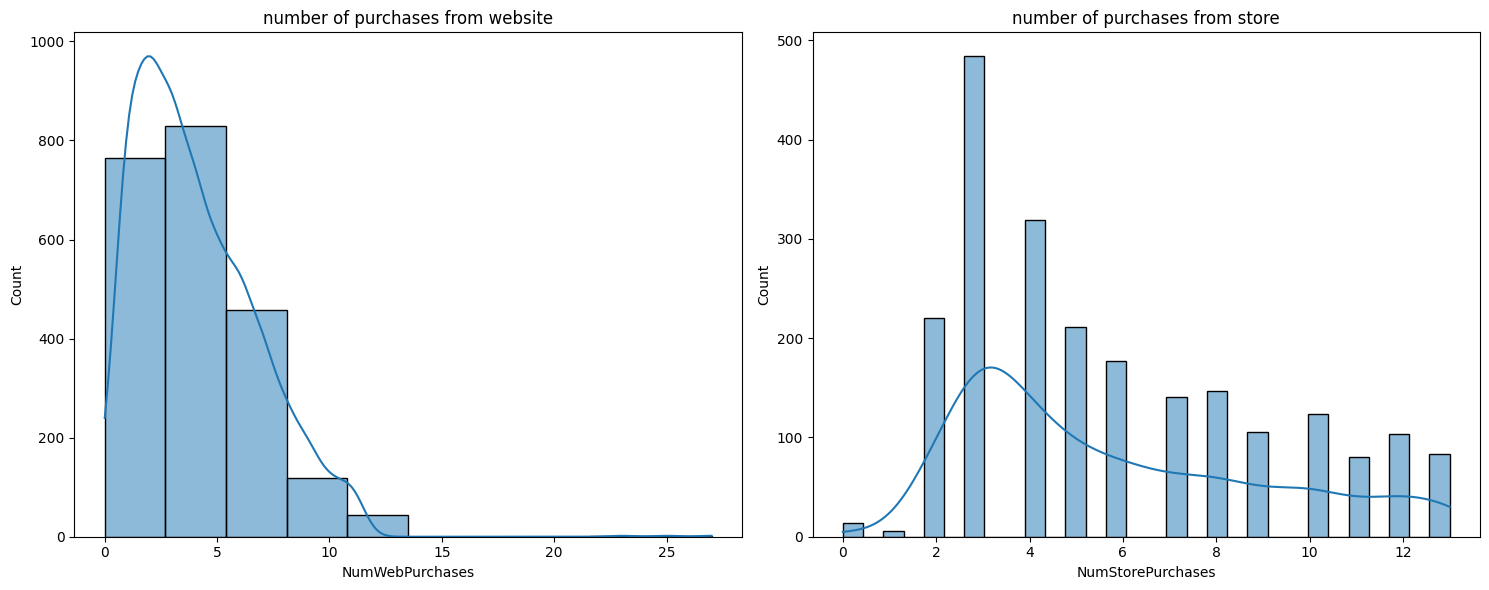

In [26]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['NumWebPurchases'], bins=10, kde=True, ax=ax[0])
ax[0].set_title("number of purchases from website")

sns.histplot(df['NumStorePurchases'], bins=30, kde=True, ax=ax[1])
ax[1].set_title("number of purchases from store")

plt.tight_layout()
plt.show()

- `NumWebPurchases` is **highly right-skewed**, with the majority of customers making between **0 and 5 web purchases** and relatively few customers making a larger number of purchases.

- `NumStorePurchases` is concentrated around lower purchase frequencies, with **2 purchases being the most common**, followed by **4 purchases**.

In [27]:
print('Skewness:')
print(f"NumWebPurchases: {df['NumWebPurchases'].skew() :.4f}")
print(f"NumStorePurchases: {df['NumStorePurchases'].skew() :.4f}")

Skewness:
NumWebPurchases: 1.1970
NumStorePurchases: 0.7018


- `NumWebPurchases` is **highly skewed**, we have to apply transformation to reduce skewness. Also `NumStorePurchases` is moderately skewed.

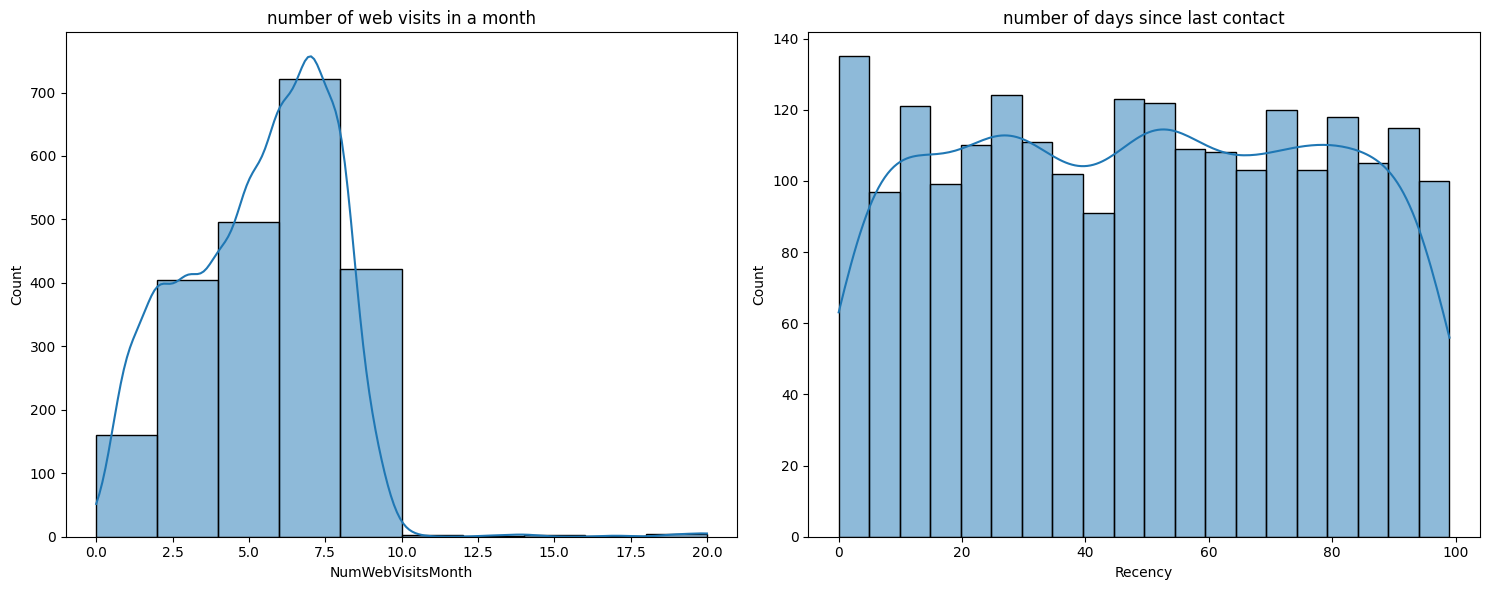

In [28]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['NumWebVisitsMonth'], bins=10, kde=True, ax=ax[0])
ax[0].set_title("number of web visits in a month")

sns.histplot(df['Recency'], bins=20, kde=True, ax=ax[1])
ax[1].set_title("number of days since last contact")

plt.tight_layout()
plt.show()

In [29]:
print('Skewness:')
print(f"NumWebVisitsMonth: {df['NumWebVisitsMonth'].skew() :.4f}")
print(f"Recency: {df['Recency'].skew() :.4f}")

Skewness:
NumWebVisitsMonth: 0.2180
Recency: 0.0016


In [30]:
corr = df[['Income', 'Recency', 'Age', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases']].corr()

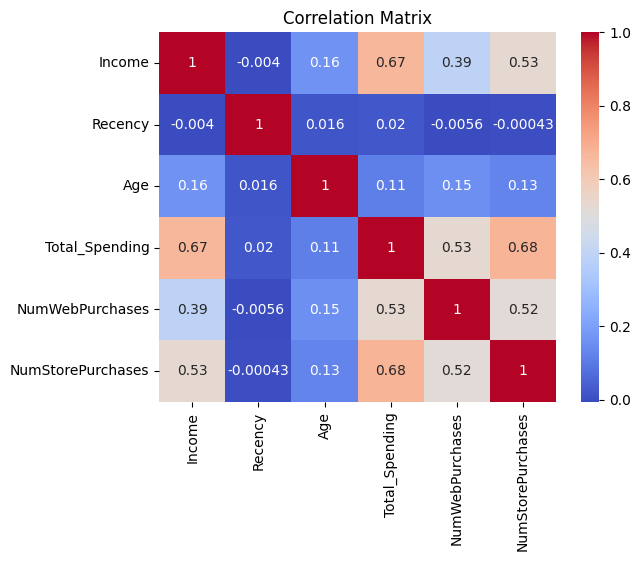

In [31]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [32]:
group_1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)
group_1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

In [33]:
group_2 = df.groupby('Education')['Income'].mean().sort_values(ascending=False)
group_2

Education
PhD           56145.313929
Master        52917.534247
Graduation    52720.373656
2n Cycle      47633.190000
Basic         20306.259259
Name: Income, dtype: float64

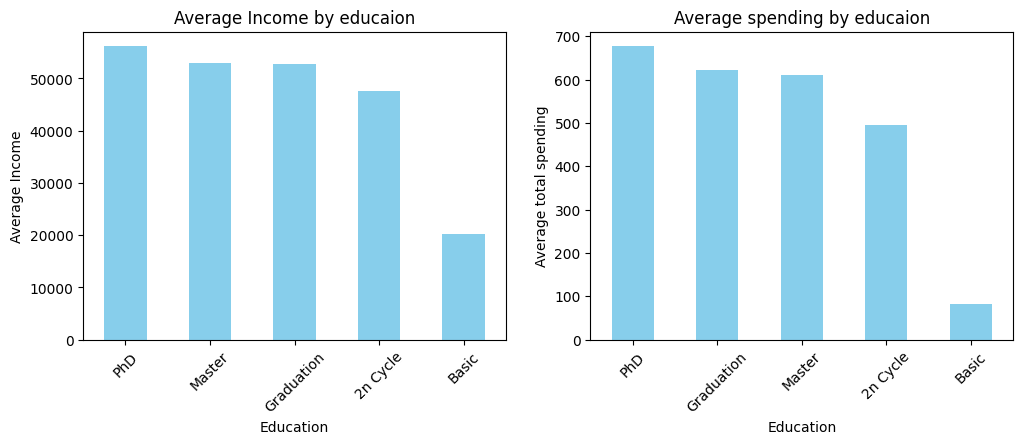

In [34]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

group_2.plot(kind='bar', color='skyblue', ax=ax[0])
ax[0].set_title('Average Income by educaion')
ax[0].set_ylabel('Average Income')
ax[0].tick_params(axis='x', rotation=45)

group_1.plot(kind='bar', color='skyblue', ax=ax[1])
ax[1].set_title('Average spending by educaion')
ax[1].set_ylabel('Average total spending')
ax[1].tick_params(axis='x', rotation=45)
plt.show()

- We can observe that customers having higher education tend to sepend more than those with basic and 2n cycle eduction. This features also have moderate correlation(~0.67) with each other.

In [35]:
## Creating new feature based on whether customer accepted any campaign
df['AcceptedCampaigns'] = df[['AcceptedCmp3', 'AcceptedCmp4', 
                        'AcceptedCmp5', 'AcceptedCmp1',
                        'AcceptedCmp2', 'Response']].sum(axis=1)

In [36]:
## Creating new feature based on whether customer accepted any campaign
df['AcceptedAny'] = df['AcceptedCampaigns'].apply(lambda x:1 if x>0 else 0)

In [37]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']

In [38]:
## Creating new feature as Age group
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [39]:
group_3 = df.groupby('AgeGroup')['Income'].mean().round(2)
group_3

AgeGroup
18-29    10960.50
30-39    47905.48
40-49    48057.59
50-59    50479.32
60-69    55980.03
70+      58767.08
Name: Income, dtype: float64

In [40]:
group_4 = df.groupby('AgeGroup')['Total_Spending'].mean().round(2)
group_4

AgeGroup
18-29     69.00
30-39    651.77
40-49    500.46
50-59    552.66
60-69    676.23
70+      744.38
Name: Total_Spending, dtype: float64

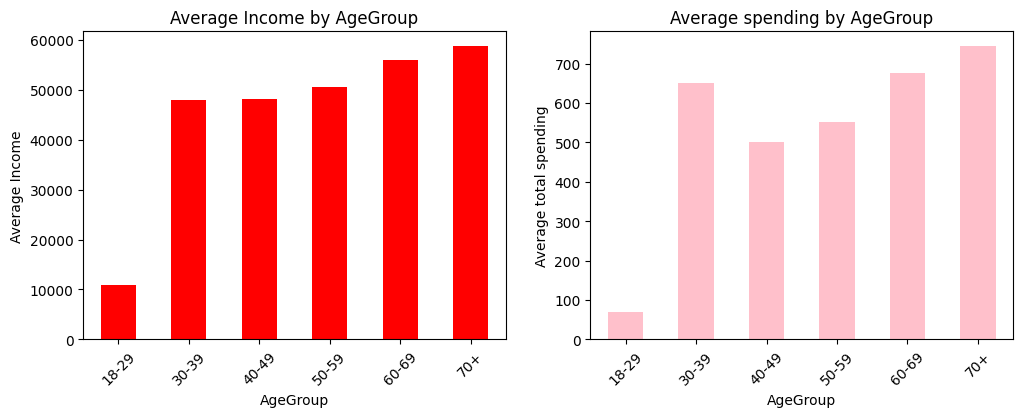

In [41]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

group_3.plot(kind='bar', color='red', ax=ax[0])
ax[0].set_title('Average Income by AgeGroup')
ax[0].set_ylabel('Average Income')
ax[0].tick_params(axis='x', rotation=45)

group_4.plot(kind='bar', color='pink', ax=ax[1])
ax[1].set_title('Average spending by AgeGroup')
ax[1].set_ylabel('Average total spending')
ax[1].tick_params(axis='x', rotation=45)
plt.show()

- **Average income increases substantially with age**. The 18–29 age group has the lowest average income, while customers aged 60–69 and 70+ have the highest average income.

- In terms of total spending, the 18–29 age group has by far the lowest average spending. Spending increases for the 30–39 group, decreases for the 40–49 and 50–59 groups and increases again among customers aged 60–69 and 70+.

- Interestingly, although the average income of customers aged **30–39, 40–49, and 50–59 is relatively similar**, the 30–39 group has considerably higher average spending than the 40–49 and 50–59 groups. This suggests that income alone may not explain differences in spending behavior across age groups.

- The relatively high income and spending observed among the 70+ group may be influenced by outliers or the relatively small sample size of this age group.

### Clustering

In [46]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
X1 = df[features].copy()

In [47]:
X1.shape[0]

2216

In [48]:
outlier_summary = {'features': [], 'lower_bound': [], 'upper_bound': [], 'outliers': [], 'outliers_percentage': []}
for feature in X1.columns:
    Q1 = X1[feature].quantile(0.25)
    Q3 = X1[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR*1.5
    upper_bound = Q3 + IQR*1.5

    outlier = X1[(X1[feature] < lower_bound) | (X1[feature] > upper_bound)]

    outlier_percentage = (len(outlier)/X1.shape[0])*100

    outlier_summary['features'].append(feature)
    outlier_summary['lower_bound'].append(lower_bound)
    outlier_summary['upper_bound'].append(upper_bound)
    outlier_summary['outliers'].append(len(outlier))
    outlier_summary['outliers_percentage'].append(round(outlier_percentage, 2))
    

In [49]:
outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,features,lower_bound,upper_bound,outliers,outliers_percentage
0,Age,22.0,94.0,3,0.14
1,Income,-14525.5,118350.5,8,0.36
2,Total_Spending,-1399.5,2516.5,3,0.14
3,NumWebPurchases,-4.0,12.0,3,0.14
4,NumStorePurchases,-4.5,15.5,0,0.00
5,NumWebVisitsMonth,-3.0,13.0,8,0.36
6,Recency,-51.0,149.0,0,0.00


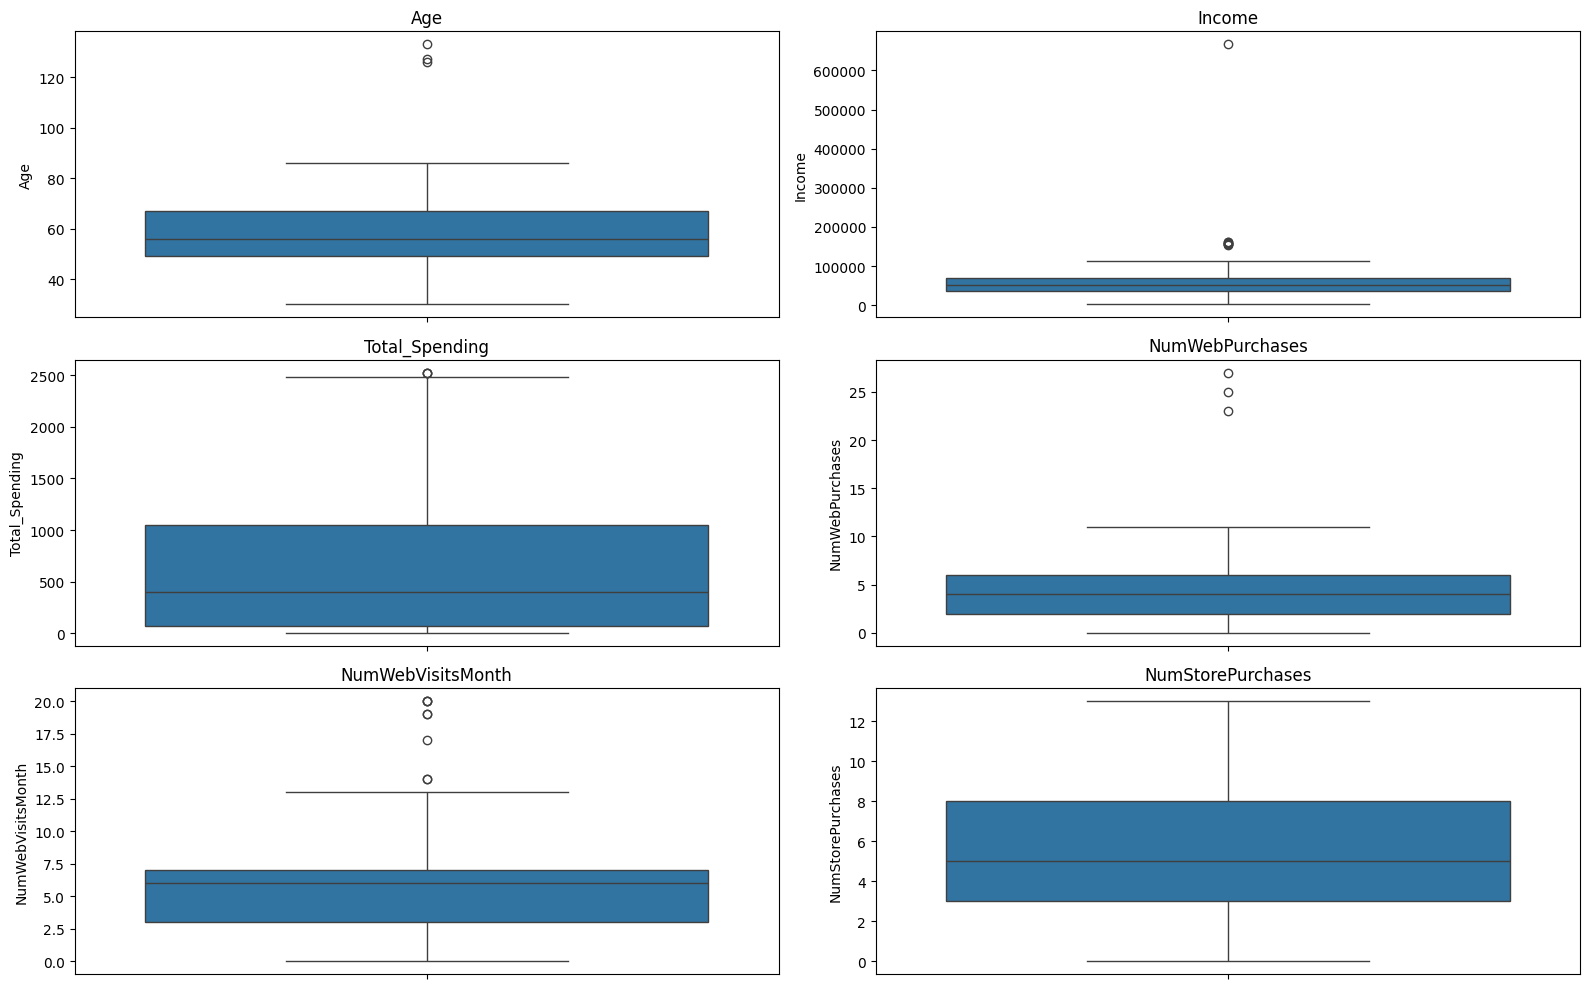

In [50]:
columns = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumWebVisitsMonth', 'NumStorePurchases']
fig,ax = plt.subplots(3,2, figsize=(16,10))
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(X1[col], ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [52]:
X_scaled = scalar.fit_transform(X1)

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from kneed import KneeLocator

In [55]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X1)

In [56]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

  File "c:\Users\theis\.conda\envs\segmentenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\theis\.conda\envs\segmentenv\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\theis\.conda\envs\segmentenv\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\theis\.conda\envs\segmentenv\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [57]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,10218.620144,0.321512,1.287115
3,9007.752707,0.264457,1.669448
4,8158.801654,0.194696,1.752359
5,7567.381030,0.191760,1.747026
6,7008.932060,0.192633,1.458474
7,6627.152803,0.185992,1.527182
8,6157.174734,0.185515,1.442867
9,5873.540023,0.181007,1.445171


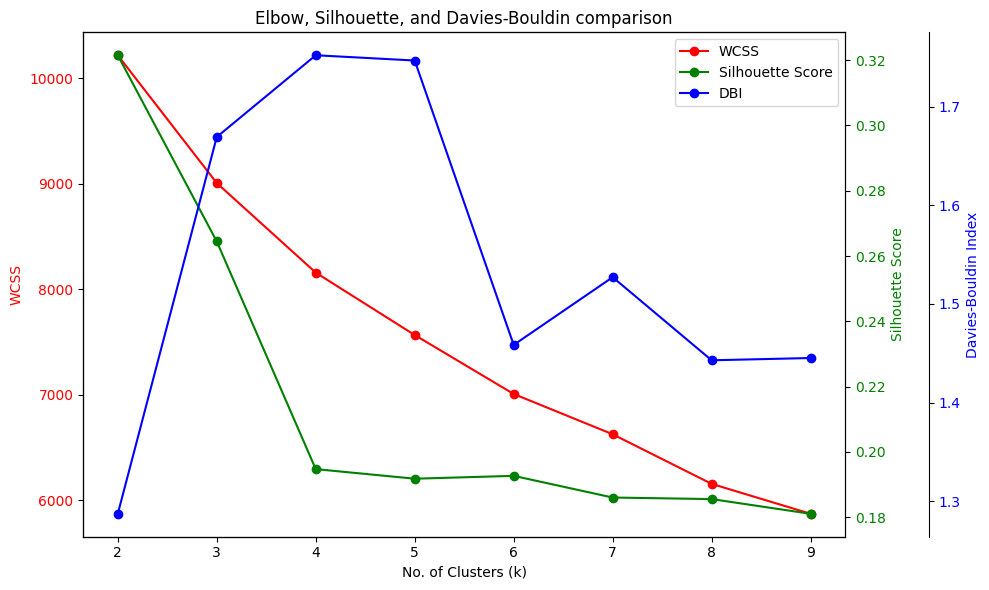

In [58]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

- WCSS (red): Decreases smoothly across all k, no clear elbow bend.
- Silhouette (green): Peaks at k=2 (~0.32), drops sharply and stays low (~0.18–0.19) from k=4 through k=8.
- DBI (blue): Best (lowest) at k=2 (~1.28), worst (highest) at k=4 (~1.73), gradually improves again toward k=8–9.

In [59]:
K = range(2,10)
knee = KneeLocator(K,
                   wcss,
                   curve='convex',
                   direction='decreasing')

print('Optimal_K:', knee.elbow)

Optimal_K: 4


- **k=4**, despite looking plausible on the WCSS curve, is actually near the **worst point for both silhouette and DBI** (*separation is weakest there, not strongest*).
- No k shows consistent agreement across all three metrics. 

### Likely causes
1. correlated/redundant features
2. high dimensionality relative to sample size after one-hot encoding
3. skewed distributions.

In [60]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
X2 = df[features].copy()

In [64]:
X2['Income'] = X2['Income'].astype('int64')

In [65]:
X2['Income'] = np.log1p(X2['Income'])
X2['NumWebPurchases'] = np.log1p(X2['NumWebPurchases'])
X2['Total_Spending'] = np.log1p(X2['Total_Spending'])
X2['NumStorePurchases'] = np.sqrt(X2['NumStorePurchases'])

In [67]:
for feature in ['Income', 'NumWebPurchases', 'Total_Spending', 'NumStorePurchases']:
    print(f"{feature}: {X2[feature].skew():.4f}")

Income: -1.1680
NumWebPurchases: -0.2789
Total_Spending: -0.3728
NumStorePurchases: 0.1571


In [68]:
X2['Income'] = np.expm1(X2['Income'])
X2['Total_Spending'] = np.expm1(X2['Total_Spending'])

- Since applying the **log(1+x) transformation did not substantially reduce the skewness**, we applied the **Yeo-Johnson transformation** as an alternative approach to improve the distribution's symmetry.

In [69]:
from sklearn.preprocessing import PowerTransformer
yeo_john = PowerTransformer(method='yeo-johnson')

In [70]:
X2['Income'] = X2['Income'].astype('int64')

In [71]:
X2[['Income', 'Total_Spending']] = yeo_john.fit_transform(X2[['Income', 'Total_Spending']])

In [72]:
for feature in ['Income',  'Total_Spending']:
    print(f"{feature}: {X2[feature].skew():.4f}")

Income: 0.2270
Total_Spending: -0.1207


In [73]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X2)

In [74]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

In [75]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,7302.792166,0.397445,1.004665
3,6124.041019,0.298556,1.376605
4,5480.456407,0.289976,1.295893
5,4867.790139,0.235083,1.405489
6,4506.743083,0.225219,1.382029
7,4248.403202,0.216013,1.378437
8,4014.774903,0.215314,1.402553
9,3807.429966,0.212585,1.302282


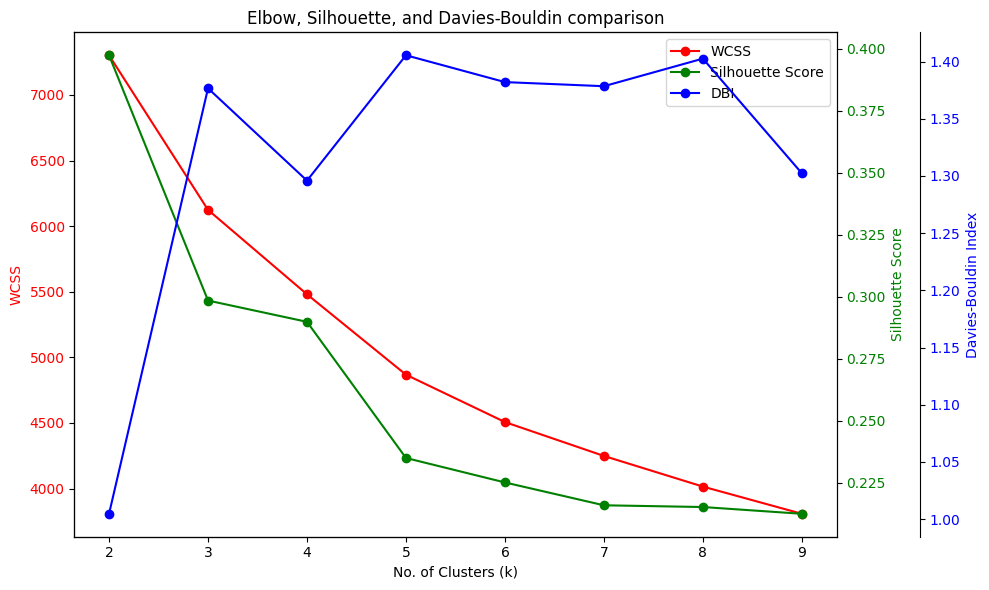

In [76]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

In [77]:
K = range(2,10)
knee = KneeLocator(K,
                   wcss,
                   curve='convex',
                   direction='decreasing')

print('Optimal_K:', knee.elbow)

Optimal_K: 5


- Skew correction improved one metric's stability (silhouette) but didn't resolve the core issue.
- DBI's behavior around k=5 and k=8 suggests there's still something distorting separation at that specific point and more broadly, no k in the 3–9 range shows strong, corroborated cluster structure.

### Likely cause
1. correlated features 

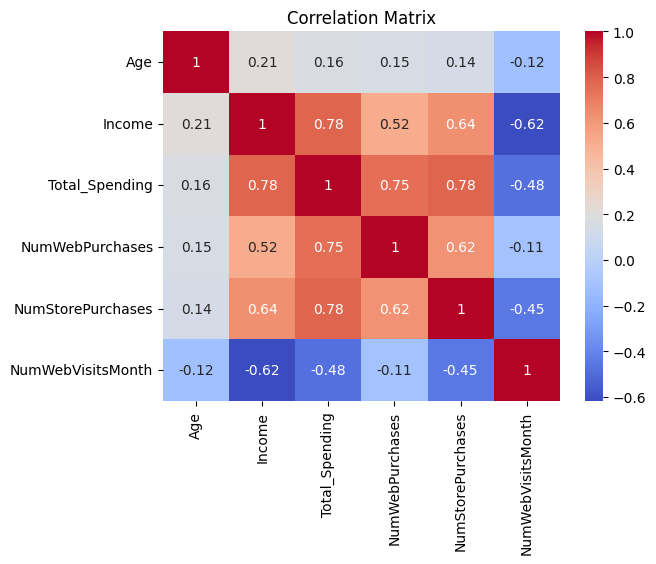

In [79]:
corr = X2.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- `Total_Spending` has moderate to high correlation to all features. We will drop `Total_Spending` and see whether results will improve or not.

In [80]:
X2.drop('Total_Spending', axis=1, inplace=True)

In [81]:
X_scaled = scalar.fit_transform(X2)

In [82]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

In [83]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,6755.224727,0.354285,1.131391
3,5646.707679,0.285129,1.391159
4,4989.302132,0.280994,1.271028
5,4411.186296,0.241327,1.355708
6,4107.075454,0.223380,1.304773
7,3838.824235,0.221315,1.308409
8,3587.562504,0.224061,1.229747
9,3448.824980,0.210125,1.350190


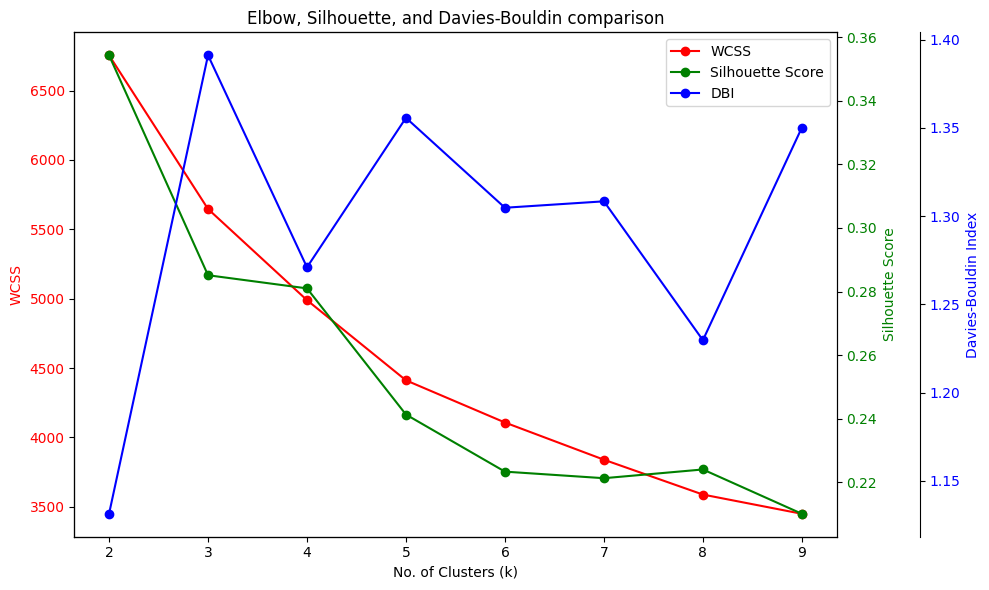

In [84]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

- WCSS(red): decreases continuously as the number of clusters increases. After k=5-6 improvement becomes smaller.
- Silhouette (green): The score is highest at k = 2 (~0.35) and generally decreases as the number of clusters increases. This indicates that the cluster separation and cohesion are strongest at k = 2 among the tested values.
- DBI(blue): The lowest DBI occurs at k = 2 (~1.17), while k = 3 has the highest value. After k = 4, the DBI fluctuates but remains higher than at k = 2.

In [85]:
K = range(2,10)
knee = KneeLocator(K,
                   wcss,
                   curve='convex',
                   direction='decreasing')

print('Optimal_K:', knee.elbow)

Optimal_K: 5


### Hierarchial Clustering

In [86]:
import scipy.cluster.hierarchy as hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist

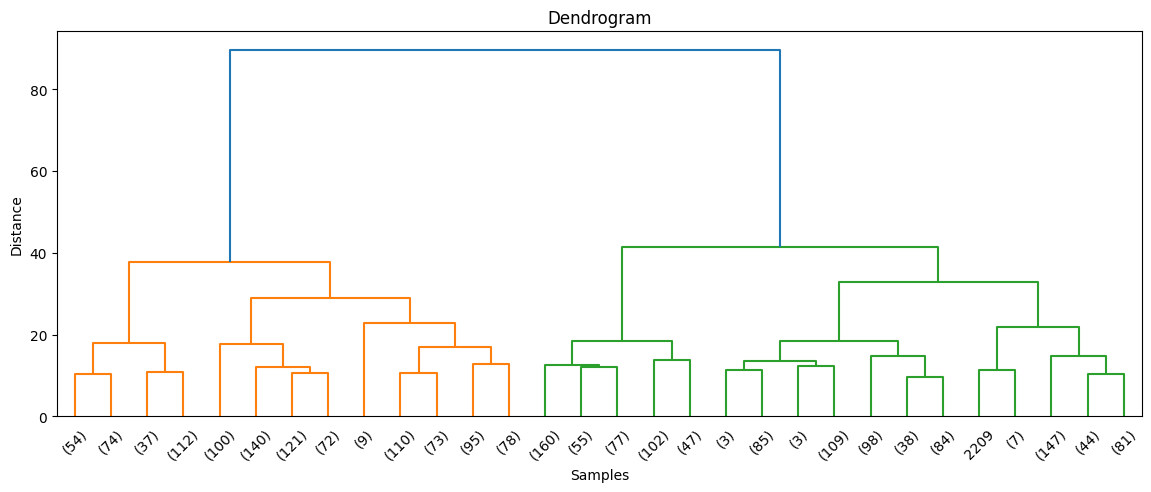

In [87]:
## ward linkage
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30)  # truncate for readability with many samples
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [88]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenetic correlation: {coph_corr:.4f}")

cophenetic correlation: 0.5417


- Since **cophenetic correlation <0.6** indicate dendrogram distorts the actual distance relationships.

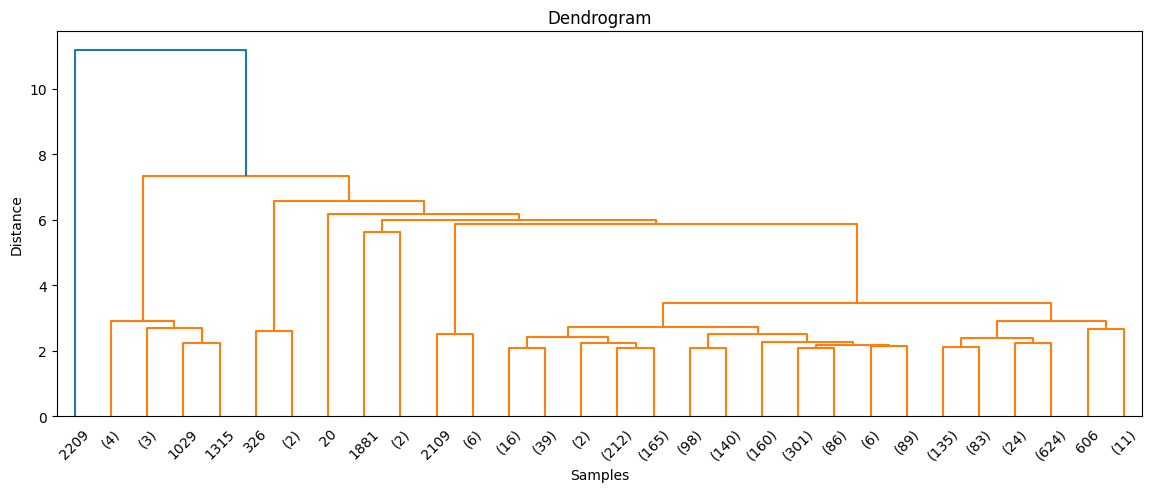

In [89]:
## Average Linkage
Z = linkage(X_scaled, method='average')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [90]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenetic correlation: {coph_corr:.4f}")

cophenetic correlation: 0.7390


- Moderate **cophenetic correlation(~0.74)**.

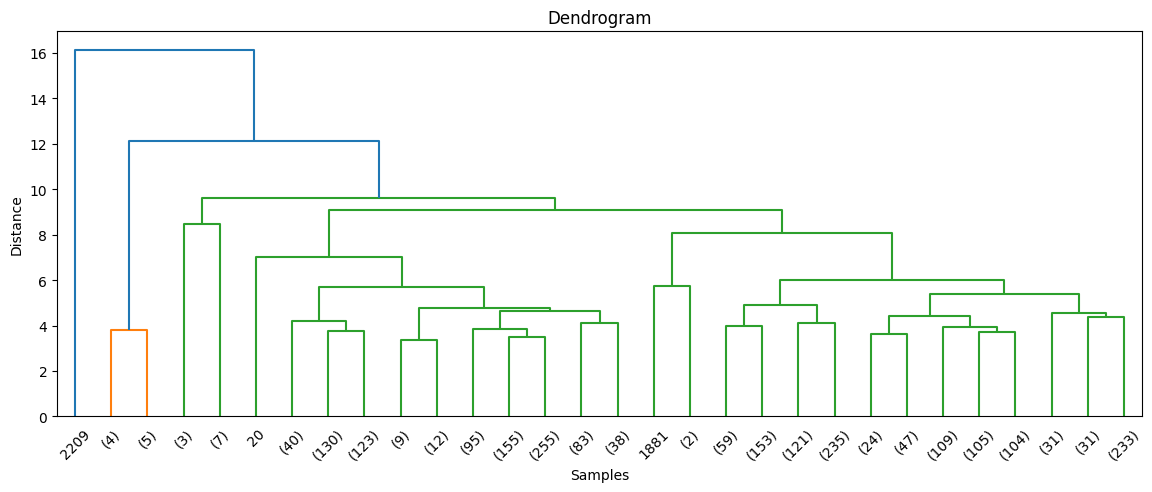

In [91]:
## complete linkage
Z = linkage(X_scaled, method='complete')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [92]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenet correlation: {coph_corr:.4f}")

cophenet correlation: 0.6429


- Moderate **cophenetic correlation(~0.64)**.

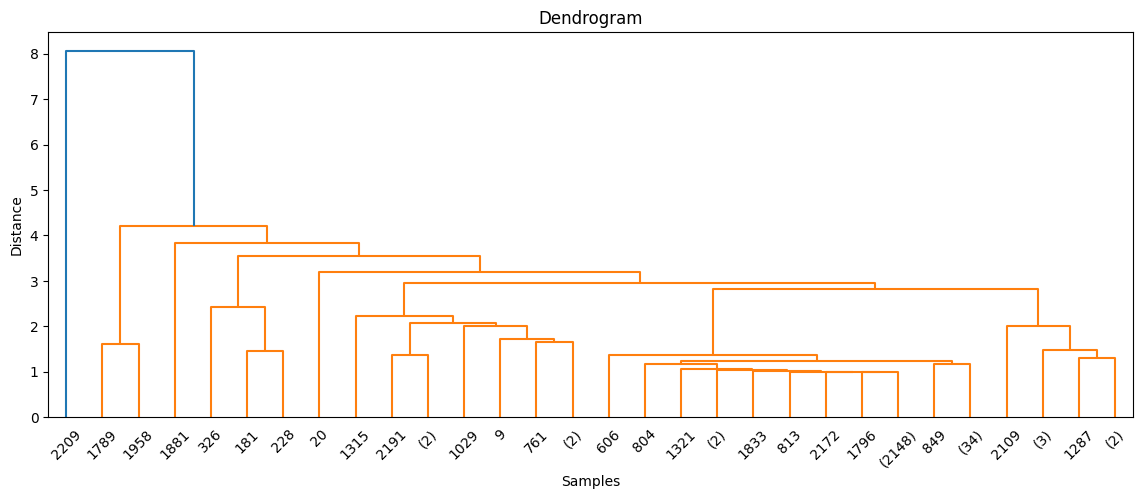

In [93]:
## single linkage
Z = linkage(X_scaled, method='single')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [94]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenet correlation: {coph_corr:.4f}")

cophenet correlation: 0.5380


- Since **cophenetic correlation <0.6** indicate dendrogram distorts the actual distance relationships. 

In [95]:
coph_corr_df = pd.DataFrame({'cophenet_corr': [0.5380, 0.6429, 0.7390, 0.5417]}, index=['single', 'complete', 'average', 'ward'])
coph_corr_df

,cophenet_corr
single,0.5380
complete,0.6429
average,0.7390
ward,0.5417


- **Average linkage** is clearly the best fit for data's actual distance structure, landing in the **"moderate, usable"** range (0.6–0.75).

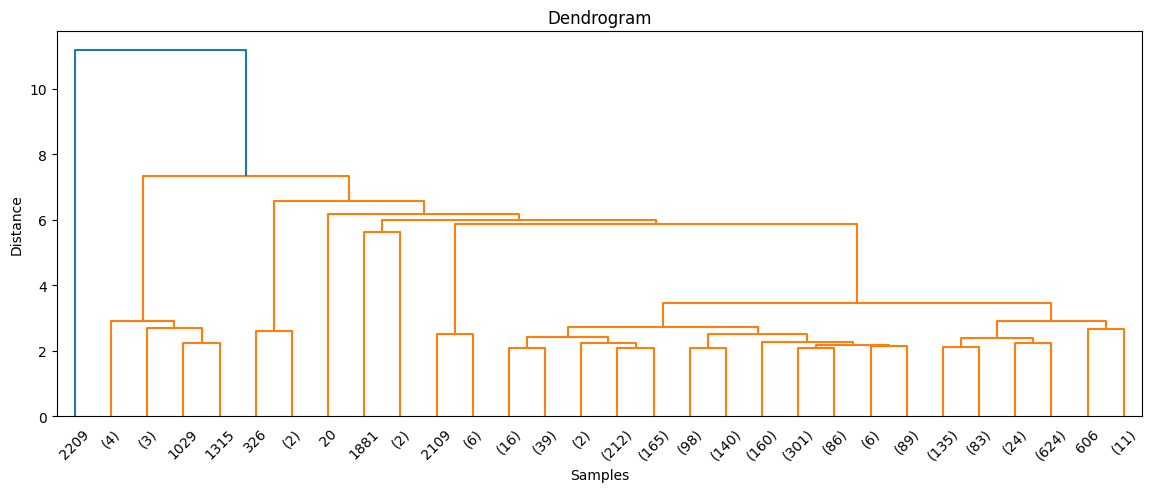

In [96]:
Z = linkage(X_scaled, method='average')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [97]:
silhoutte_scores = []
dbi_scores = []
Z = linkage(X_scaled, method='average')
for k in range(2,10):
    labels = fcluster(Z, k, criterion='maxclust')
    silhoutte_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

evaluation_metrics = pd.DataFrame({'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,Silhouetter Scores,DBI
2,0.739094,0.190748
3,0.594823,0.425094
4,0.526288,0.456390
5,0.481801,0.434830
6,0.462596,0.595330
7,0.450658,0.593247
8,0.444450,0.458172
9,0.340746,0.557882


In [98]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenet correlation: {coph_corr:.4f}")

cophenet correlation: 0.7390


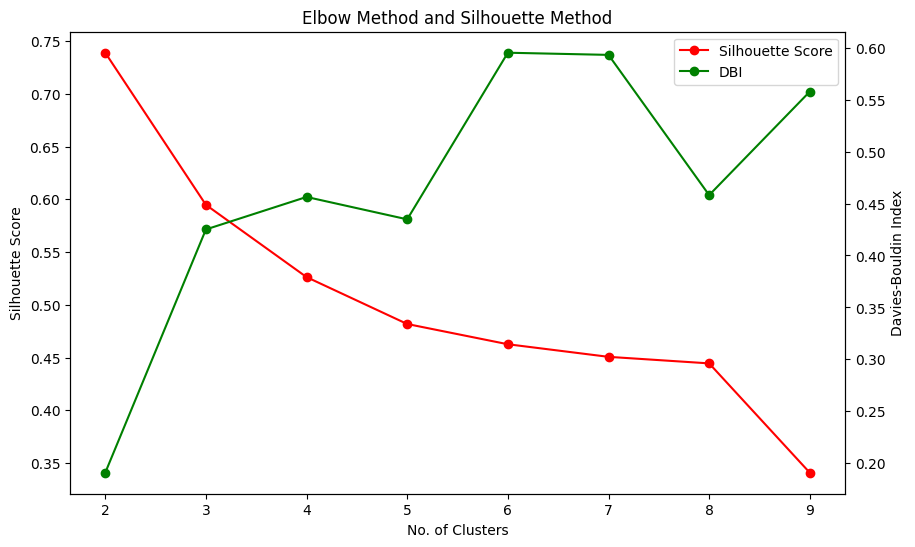

In [99]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Silhouette Score
line1, = ax1.plot(range(2, 10), silhoutte_scores, marker='o', label='Silhouette Score', color=color1)
ax1.set_xlabel('No. of Clusters')
ax1.set_ylabel('Silhouette Score')

# DBI
ax2 = ax1.twinx()
line2, = ax2.plot(range(2, 10), dbi_scores, marker='o', label='DBI', color=color2)
ax2.set_ylabel('Davies-Bouldin Index')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow Method and Silhouette Method')

plt.show()

- Silhouetter Score: Highest at k=2(strong and well separated clusters ~0.74), then declines from k=8.
- DBI: Lowest at k=2(best) spikes and stays high through most of the middle range, worst around k=6-7.

- Both metric strongly agrees at **k=2** for both KMeans and Hierarchial(Average Linkage) clustering algorithms.
- But due to **Average Linkage's tendency towards chaining** we should check is it actually two well separated groups or is it one dominant cluster plus a tiny, distant outlier cluster.

In [100]:
labels = fcluster(Z, t=2, criterion='maxclust')
print(np.unique(labels, return_counts=True))

(array([1, 2], dtype=int32), array([2215,    1], dtype=int64))


- There are **2215** customers in one cluster and **only one** in another cluster. That single point is so extreme/outlier from everyone else that Average Linkage split it off as separate cluster, this results in inflated silhouette score. The 0.71 silhouette wasen't evidence of two clean clusters, it was one extreme outlier distorting result. 

In [101]:
outlier_idx = np.where(labels == 2)[0]
X2.iloc[outlier_idx]

,Age,Income,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
2233,49,10.944772,1.386294,1.732051,6


- Rerun by removing outlier

In [102]:
X_scaled_clean = np.delete(X_scaled, outlier_idx, axis=0)

In [103]:
silhoutte_scores = []
dbi_scores = []
Z = linkage(X_scaled_clean, method='average')
for k in range(2,10):
    labels = fcluster(Z, k, criterion='maxclust')
    silhoutte_scores.append(silhouette_score(X_scaled_clean, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled_clean, labels))

evaluation_metrics = pd.DataFrame({'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,Silhouetter Scores,DBI
2,0.595371,0.543095
3,0.526526,0.545664
4,0.482019,0.496429
5,0.462805,0.674901
6,0.450861,0.659209
7,0.444650,0.496936
8,0.340900,0.607334
9,0.339370,0.720437


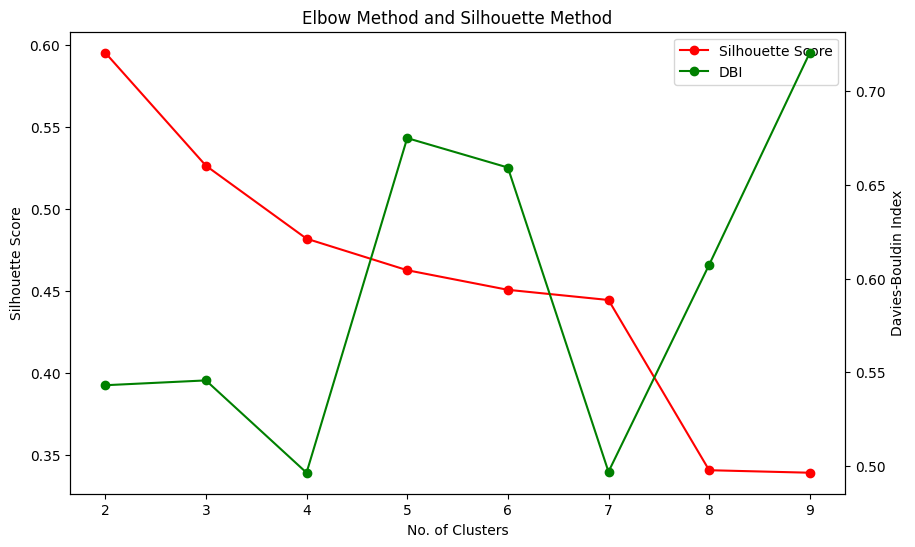

In [104]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Silhouette Score
line1, = ax1.plot(range(2, 10), silhoutte_scores, marker='o', label='Silhouette Score', color=color1)
ax1.set_xlabel('No. of Clusters')
ax1.set_ylabel('Silhouette Score')

# DBI
ax2 = ax1.twinx()
line2, = ax2.plot(range(2, 10), dbi_scores, marker='o', label='DBI', color=color2)
ax2.set_ylabel('Davies-Bouldin Index')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow Method and Silhouette Method')

plt.show() 

In [ ]:
labels = fcluster(Z, t=4, criterion='maxclust')
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4], dtype=int32),
 array([   9,    3, 2202,    1], dtype=int64))

- Cluster assignments remain **inconsistent after applying improvements**, indicating that the **selected features should be re-evaluated** to ensure they provide stable and meaningful separation between customer segments.

### Using different set of features

In [ ]:
## Dropping customers of age 100 and above. 
df.drop(list(df.index[df['Age'] >= 100]), axis=0, inplace=True)
df.shape

(2213, 36)

In [107]:
df.index[df['Income'] == df['Income'].max()]

Index([2233], dtype='int64')

In [108]:
## Income of 666666 is likely data error
df.drop(2233, axis=0, inplace=True)

In [109]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
X3 = df[features].copy()

In [110]:
X3['Age'].max(), X3['Age'].min()

(86, 30)

- Previously, we observed that approximately **55% of customers belong to the 40–60 age range**. Based on this observation, we created a new **`AgeGroup`** feature and incorporated it into the clustering process to capture age-related differences in customer behavior.

In [111]:
bins = [18, 40 ,60, 140]
labels = ['18-39', '40-59', '60+']
X3['AgeGroup'] = pd.cut(X3['Age'], bins=bins, labels=labels)

In [112]:
X3['AgeGroup'].value_counts()

AgeGroup
40-59    1179
60+       846
18-39     187
Name: count, dtype: int64

In [113]:
X3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  2212 non-null   int64   
 1   Income               2212 non-null   float64 
 2   Total_Spending       2212 non-null   int64   
 3   NumWebPurchases      2212 non-null   int64   
 4   NumCatalogPurchases  2212 non-null   int64   
 5   NumStorePurchases    2212 non-null   int64   
 6   AgeGroup             2212 non-null   category
dtypes: category(1), float64(1), int64(5)
memory usage: 123.3 KB


In [114]:
X3['Income'] = X3['Income'].astype('int64')

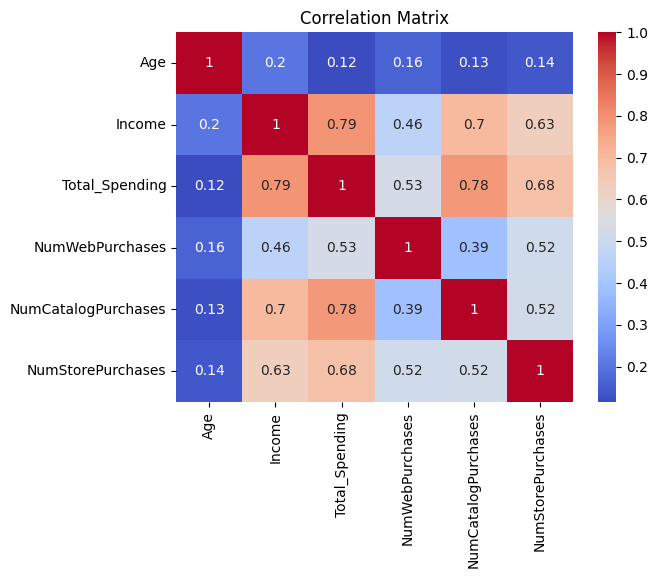

In [115]:
corr_matrix = X3.select_dtypes(include='int').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- `Total_spending` has moderate correlation with `Income`, `NumWebPurchases`, `NumCatalogPurchases`.        

In [116]:
X3.drop('Total_Spending', axis=1, inplace=True)

In [118]:
outlier_summary = {'features': [], 'lower_bound': [], 'upper_bound': [], 'outliers': [], 'outlier_perct': []}
for feature in X3.select_dtypes(include='int'):
    Q1 = X3[feature].quantile(0.25)
    Q3 = X3[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR*1.5
    upper_bound = Q3 + IQR*1.5

    outliers = X3[(X3[feature] > upper_bound) | (X3[feature] < lower_bound)]

    outlier_perct = (len(outliers)/X3.shape[0])*100

    outlier_summary['features'].append(feature)
    outlier_summary['lower_bound'].append(lower_bound)
    outlier_summary['upper_bound'].append(upper_bound)
    outlier_summary['outliers'].append(len(outliers))
    outlier_summary['outlier_perct'].append(outlier_perct)

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,features,lower_bound,upper_bound,outliers,outlier_perct
0,Age,22.00,94.00,0,0.000000
1,Income,-14646.75,118367.25,7,0.316456
2,NumWebPurchases,-4.00,12.00,3,0.135624
3,NumCatalogPurchases,-6.00,10.00,23,1.039783
4,NumStorePurchases,-4.50,15.50,0,0.000000


In [119]:
for feature in X3.select_dtypes(include='int'):
    print(f"{feature}:{X3[feature].skew() :.4f}")

Age:0.0934
Income:0.3480
NumWebPurchases:1.1953
NumCatalogPurchases:1.8815
NumStorePurchases:0.6997


In [121]:
X3['NumCatalogPurchases'] = np.log1p(X3['NumCatalogPurchases'])
X3['NumStorePurchases'] = np.sqrt(X3['NumStorePurchases'])
X3['NumWebPurchases'] = np.log1p(X3['NumWebPurchases'])

In [122]:
for feature in X3.drop('AgeGroup', axis=1):
    print(f"{feature}:{X3[feature].skew() :.4f}")

Age:0.0934
Income:0.3480
NumWebPurchases:-0.2804
NumCatalogPurchases:0.1277
NumStorePurchases:0.1545


In [123]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

In [124]:
scalar = StandardScaler()
label = LabelEncoder()
X3['AgeGroup'] = label.fit_transform(X3['AgeGroup'])
X_scaled = scalar.fit_transform(X3)

In [125]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

In [126]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++', verbose=False)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

In [127]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,7903.169401,0.365850,1.107881
3,5868.513962,0.356217,1.093380
4,4767.839966,0.349031,1.059871
5,4322.687848,0.310144,1.171043
6,3983.927642,0.313226,1.141129
7,3670.620616,0.281823,1.264829
8,3372.138274,0.294745,1.236866
9,3194.903906,0.295566,1.218620


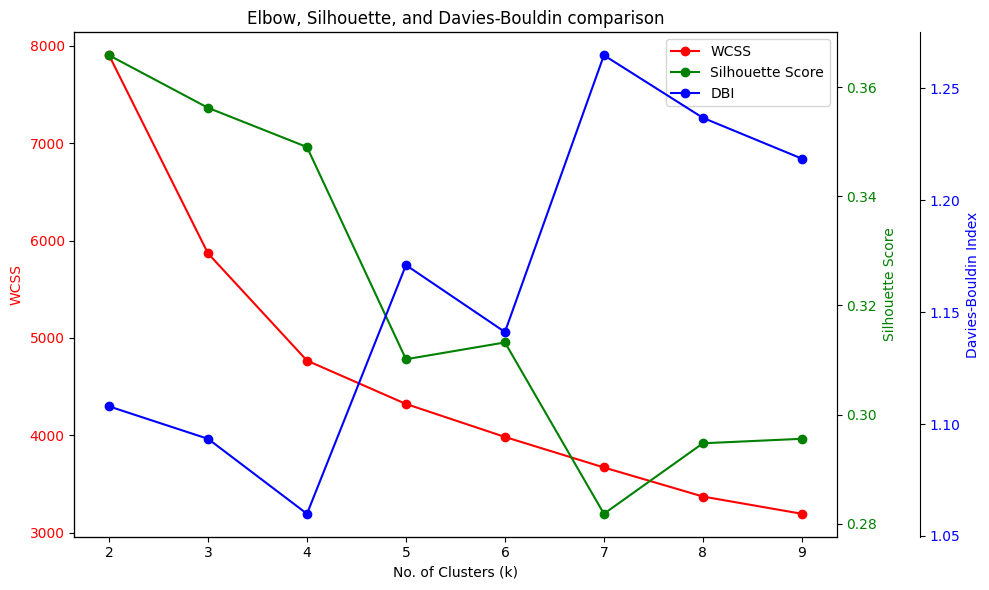

In [128]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

In [129]:
kmeans = KMeans(n_clusters=2)
df['Cluster_k2'] = kmeans.fit_predict(X_scaled)
df['Cluster_k2'].value_counts()

Cluster_k2
0    1239
1     973
Name: count, dtype: int64

In [130]:
kmeans = KMeans(n_clusters=4)
df['Cluster_k4'] = kmeans.fit_predict(X_scaled)

In [131]:
df['Cluster_k4'].value_counts()

Cluster_k4
0    721
1    645
3    559
2    287
Name: count, dtype: int64

In [132]:
bins = [18, 40 ,60, 100]
labels = ['18-39', '40-59', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [133]:
print('Cluster 0')
print(df[df['Cluster_k2'] == 0]['AgeGroup'].value_counts())
print()
print('Cluster 1')
print(df[df['Cluster_k2'] == 1]['AgeGroup'].value_counts())

Cluster 0
AgeGroup
60+      619
40-59    543
18-39     77
Name: count, dtype: int64

Cluster 1
AgeGroup
40-59    636
60+      227
18-39    110
Name: count, dtype: int64


In [134]:
print('Cluster 0')
print(df[df['Cluster_k4'] == 0]['AgeGroup'].value_counts())
print()
print('Cluster 1')
print(df[df['Cluster_k4'] == 1]['AgeGroup'].value_counts())
print()
print('Cluster 2')
print(df[df['Cluster_k4'] == 2]['AgeGroup'].value_counts())
print()
print('Cluster 3')
print(df[df['Cluster_k4'] == 3]['AgeGroup'].value_counts())

Cluster 0
AgeGroup
40-59    619
18-39    102
60+        0
Name: count, dtype: int64

Cluster 1
AgeGroup
40-59    560
18-39     85
60+        0
Name: count, dtype: int64

Cluster 2
AgeGroup
60+      287
18-39      0
40-59      0
Name: count, dtype: int64

Cluster 3
AgeGroup
60+      559
18-39      0
40-59      0
Name: count, dtype: int64


In [135]:
Cluster3_0 = df[df['Cluster_k4'] == 0]
Cluster3_1 = df[df['Cluster_k4'] == 1]
Cluster3_2 = df[df['Cluster_k4'] == 2]
Cluster3_3 = df[df['Cluster_k4'] == 3]

In [136]:
def cluster_summary(Cluster, features):
    table = {'features': [], 'min': [], 'max': [], 'diff': [], 'mean': [], 'median': [], 'mode': []}
    for feature in features:
        table['features'].append(feature)
        table['min'].append(Cluster[feature].min())
        table['max'].append(Cluster[feature].max())
        table['diff'].append(Cluster[feature].max() - Cluster[feature].min())
        table['mean'].append(Cluster[feature].mean().round(2))
        table['median'].append(Cluster[feature].median())
        table['mode'].append(Cluster[feature].mode()[0])
    table_df = pd.DataFrame(table)
    return table_df


## Cluser: Middle-Aged, Low-engagement, Low-Income customers

**Age:** Ranges from 30 to 60. Mean (49.02) and median (50) are close. The KDE shows a primary concentration around 48-58, with a smaller secondary bump near 42-45.

**Income:** Ranges from 1,730 to 153,924 a very wide range. Mean (31,887.51) and median (31,907) are nearly identical, suggesting a symmetric central distribution, but the KDE shows a detached small bump near 140,000-155,000 likely a few residual high-income outliers. This is clearly a **low-income segment**

**Total Spending:** Mean (89.85) is notably higher than median (61) with mode (37) even lower (a strong right-skew). The KDE confirms a sharp peak near 0-100 with a long thin tail extending out past 500-750. This is a **low-spending segment**, consistent with low income, though a small subgroup of higher spenders pulls the mean upward.

**Purchase Behavior:**
- **Web Purchases:** Range 0-25, heavily concentrated at the low end. mode at 1, median at 2, with the tallest bars at 1-2. A thin tail extends to 25 (likely 1-2 residual outlier points). Web is a minimally used channel here.  
- **Catalog Purchases:** Range 0-28, overwhelmingly concentrated at 0 (tallest bar by far, ~430), with most of the rest at 1. Catalog is essentially unused by this segment. The isolated bar near 28 is a residual outlier,.
- **Store Purchases:** Range 0-7. Mode and median both 3, clearly the dominant value (~350). Store is the most used channel for this group, though still modest overall.

**Education:** Graduation is the dominant category (~360, over half), followed by PhD (~115) and Master (~110). PhD and Master are close in size here, 2n Cycle (~90) and Basic (~45) make up smaller shares.

**Marital Status:** Married (~295) is the largest group, followed by Single (~175) and Together (~170). Single is notably prominent here compared to the higher-income clusters. Divorced (~65) is a smaller minority and Widow (~10) is minimal, consistent with this being a middle-aged (not older) segment. ('Alone' is negligible.)

In [137]:
cluster_summary(Cluster3_0, features)

,features,min,max,diff,mean,median,mode
0,Age,30.0,60.0,30.0,49.02,50.0,48.0
1,Income,1730.0,153924.0,152194.0,31887.51,31907.0,7500.0
2,Total_Spending,5.0,1730.0,1725.0,89.85,61.0,37.0
3,NumWebPurchases,0.0,25.0,25.0,2.13,2.0,1.0
4,NumCatalogPurchases,0.0,28.0,28.0,0.50,0.0,0.0
5,NumStorePurchases,0.0,7.0,7.0,3.05,3.0,3.0


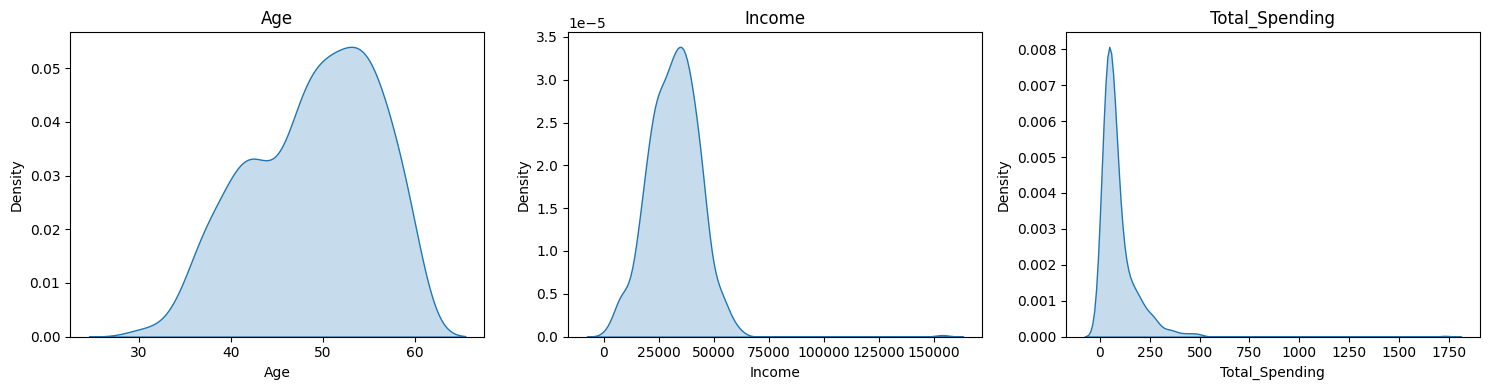

In [152]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
for i,feature in enumerate(['Age', 'Income', 'Total_Spending']):
    sns.kdeplot(Cluster3_0[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

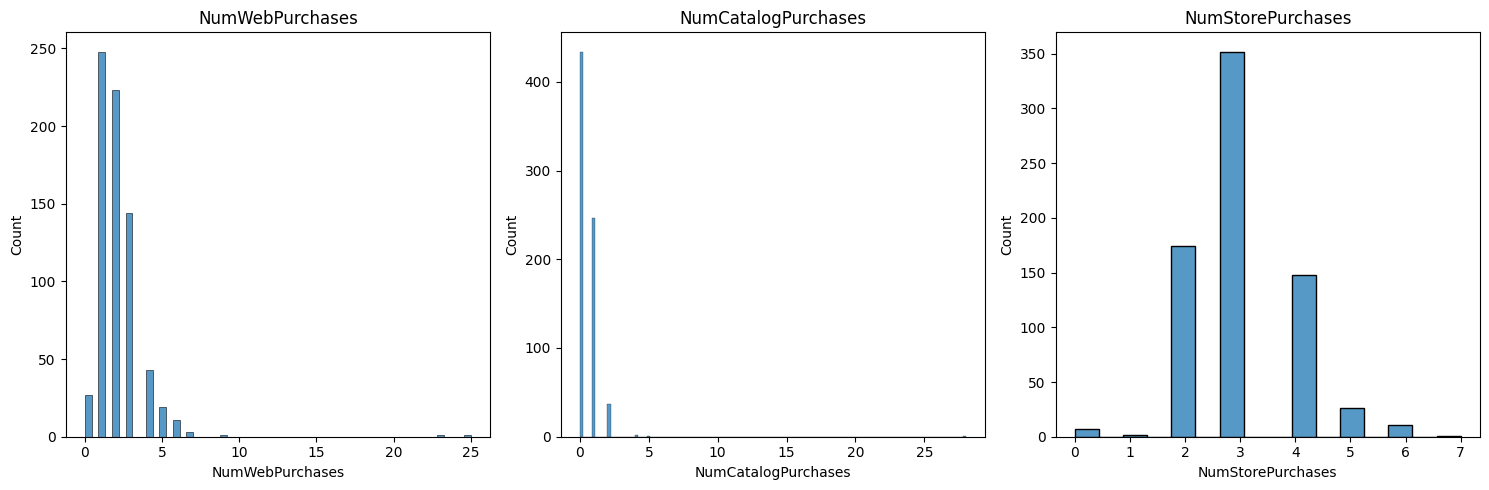

In [138]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_0[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

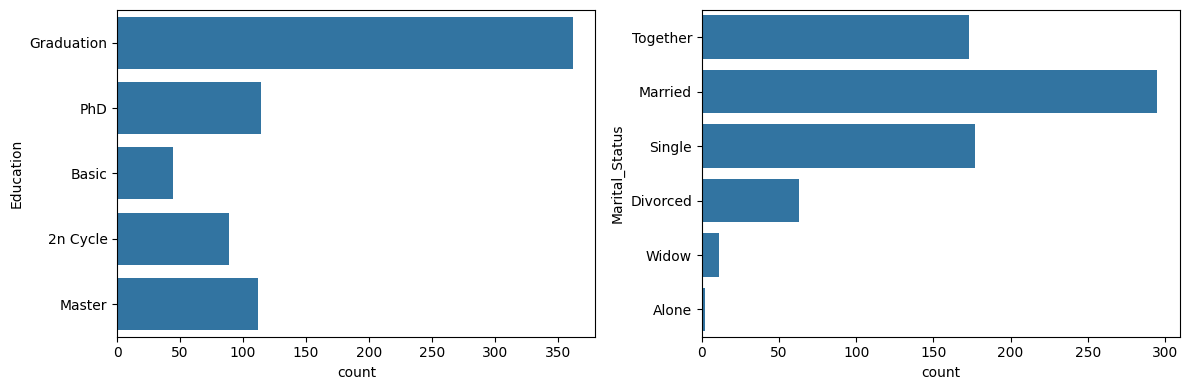

In [139]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_0['Education'], ax=ax[0])
sns.countplot(Cluster3_0['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()

## Cluser: Middle-Aged, High Value

**Age:** Ranges from 31 to 60. Mean (49.82) and median (51) are close, with mode also at 51, indicating a fairly symmetric concentration around the center. The KDE shows density heavily concentrated around 48-58, with a long thin tail tapering down toward 30. A  genuinely middle-aged-skewed segment.

**Income:** Ranges from 32,644 to 162,397. Mean (67,560.87) and median (67,445) are nearly identical, confirming a symmetric, well-behaved distribution. This is a **moderately affluent segment** — notably higher than the "Budget-Conscious Middle-Aged" cluster. The KDE shows a small detached bump near 150,000-160,000 likely a few residual high earners.

**Total Spending:** Mean (1,057.06) is somewhat higher than median (1,008), with mode (401) notably lower than both indicating right-skew, with a group of lower spenders and a group of higher spenders. The KDE shows a broad, slightly bimodal-looking shape with peaks around 500-600 and 1,000-1,100, suggesting this segment may contain two spending sub-behaviors rather than one uniform pattern. This is the **highest-spending segment** identified so far.

**Purchase Behavior:**
- **Web Purchases:** Range 0-11. Most customers made 3-8 purchases, with the tallest bar at 4 and strong activity through 5-7. A healthy, actively used channel for this group.
- **Catalog Purchases:** Range 0-28. Most customers made 1-6 purchases, peaking around 2-3, with a gradual decline thereafter. The isolated bar near 27-28 is a residual outlier, consistent with other clusters. Catalog is a secondary channel here.
- **Store Purchases:** Range 0-13. Peak around 5-6 (~90), with mean (8.14) and median (8) above that peak suggesting a secondary subgroup of more frequent in-store shoppers, similar to the bimodal pattern noted in Total_Spending. Store is this segment's strongest channel overall.

**Education:** Graduation dominates (~355, over half), followed by PhD (~145) and Master (~95). PhD again outranks Master, consistent with the higher-income clusters. 2n Cycle (~50) is a smaller minority and Basic is negligible.

**Marital Status:** Married (~260) is the clear majority, followed by Together (~160) and Single (~145). Divorced (~65) is a smaller minority and Widow (~10).

In [140]:
cluster_summary(Cluster3_1, features)

,features,min,max,diff,mean,median,mode
0,Age,31.0,60.0,29.0,49.82,51.0,51.0
1,Income,32644.0,162397.0,129753.0,67560.87,67445.0,48432.0
2,Total_Spending,59.0,2525.0,2466.0,1057.06,1008.0,401.0
3,NumWebPurchases,0.0,11.0,11.0,5.69,5.0,4.0
4,NumCatalogPurchases,0.0,28.0,28.0,4.40,4.0,2.0
5,NumStorePurchases,0.0,13.0,13.0,8.14,8.0,6.0


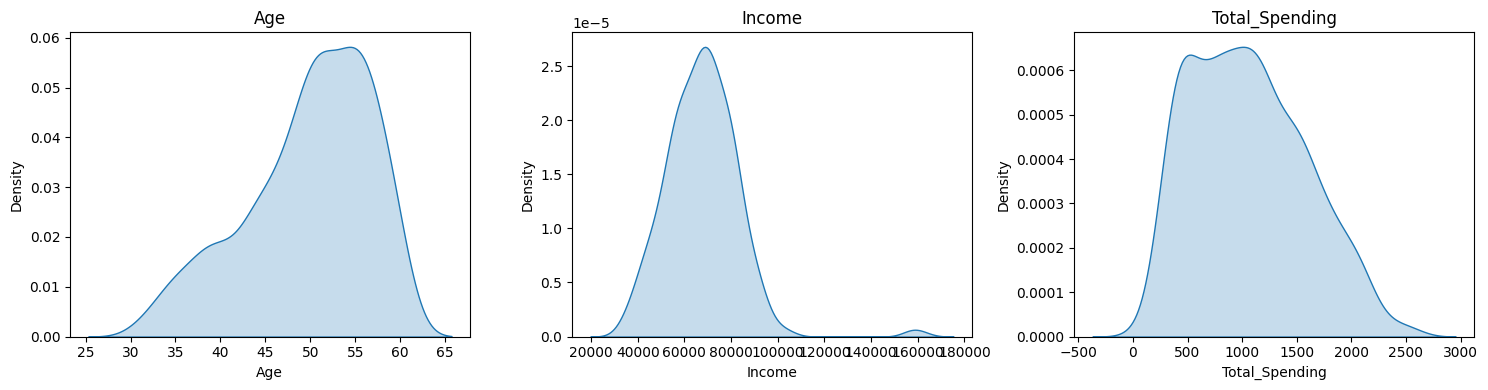

In [141]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
for i,feature in enumerate(['Age', 'Income', 'Total_Spending']):
    sns.kdeplot(Cluster3_1[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

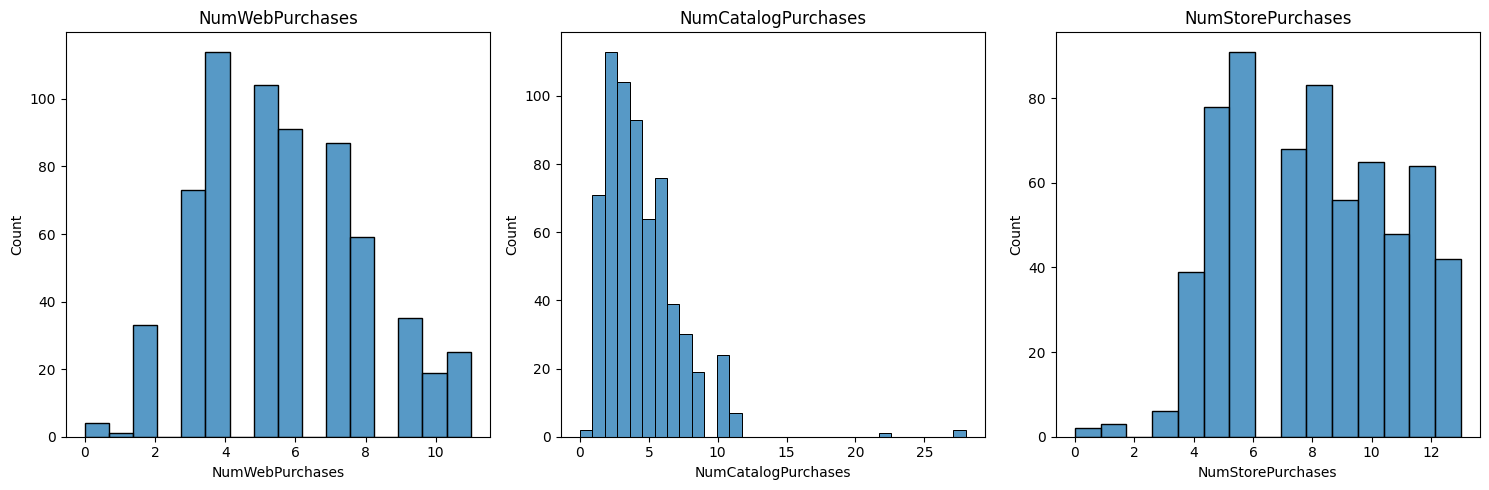

In [142]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_1[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

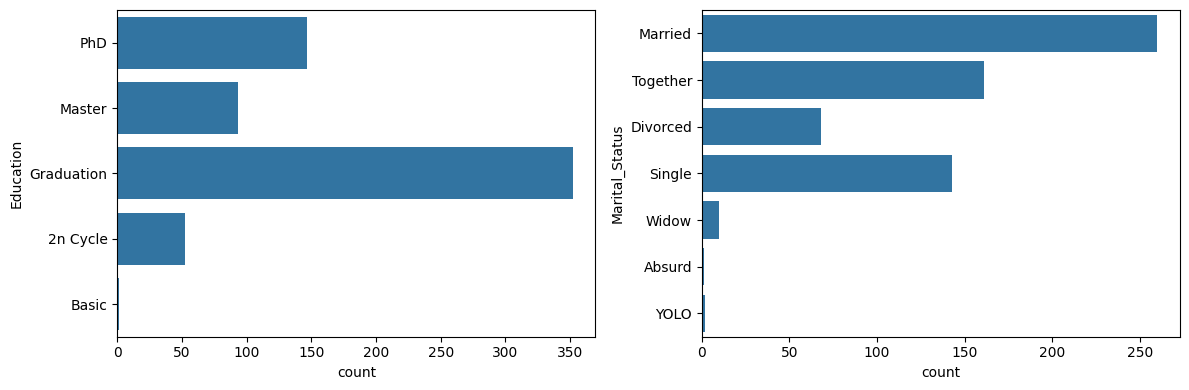

In [143]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_1['Education'], ax=ax[0])
sns.countplot(Cluster3_1['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()

## Cluster: Older, low-moderate income, lowest overall spending

**Age:** Ranges from 61 to 86. This cluster is exclusively older customers. Mean (69.25) and median (69) are close with mode at 61. The KDE shows density concentrated around 63-75, tapering off gradually toward the mid-80s. A genuinely older-skewing segment, not just "60+" at the margin.

**Income:** Ranges from 4,023 to 156,924. Mean (38,949) and median (38,823) are nearly identical, indicating a symmetric central distribution. But the KDE shows a small detached bump near 150,000, likely a residual high-income outlier. This is a **low-to-moderate income segment**.

**Total Spending:** Mean (111.12) is considerably higher than median (70), with lower mode (43). A strong right-skew. The KDE confirms a sharp peak near 0-100 with a long thin tail extending out to 700+, including a small detached bump near 700. This is a **low-spending segment**, with a small subgroup of notably higher spenders pulling the average up.

**Purchase Behavior:**
- **Web Purchases:** Range 0-7. Most customers made 1-3 purchases, with the tallest bar at 1 (~97). A modestly used, low-volume channel.
- **Catalog Purchases:** Range 0-5. Most customers made 0-1 purchases, with 0 being the single most common value (~138). Catalog is essentially unused by this segment.
- **Store Purchases:** Range 0-9. Peak clearly at 3 (~120), with mean (3.44) and median (3) aligning closely with that peak. A consistent, modest in-store shopping pattern, the most-used channel for this group.

**Education:** Graduation leads (~130), followed by PhD (~75) and Master (~55). PhD again outranks Master, consistent with most other clusters. 2n Cycle (~17) and Basic (~10) are small minorities.

**Marital Status:** Married (~95) and Together (~90) are the two largest groups, fairly close in size, followed by Single (~50). Widow (~17) is notably more prominent here than in any other cluster. Divorced (~35) is a smaller minority.

In [144]:
cluster_summary(Cluster3_2, features)

,features,min,max,diff,mean,median,mode
0,Age,61.0,86.0,25.0,69.25,69.0,61.0
1,Income,4023.0,156924.0,152901.0,38949.00,38823.0,18690.0
2,Total_Spending,6.0,711.0,705.0,111.12,70.0,43.0
3,NumWebPurchases,0.0,7.0,7.0,2.03,2.0,1.0
4,NumCatalogPurchases,0.0,5.0,5.0,0.66,1.0,0.0
5,NumStorePurchases,0.0,9.0,9.0,3.44,3.0,3.0


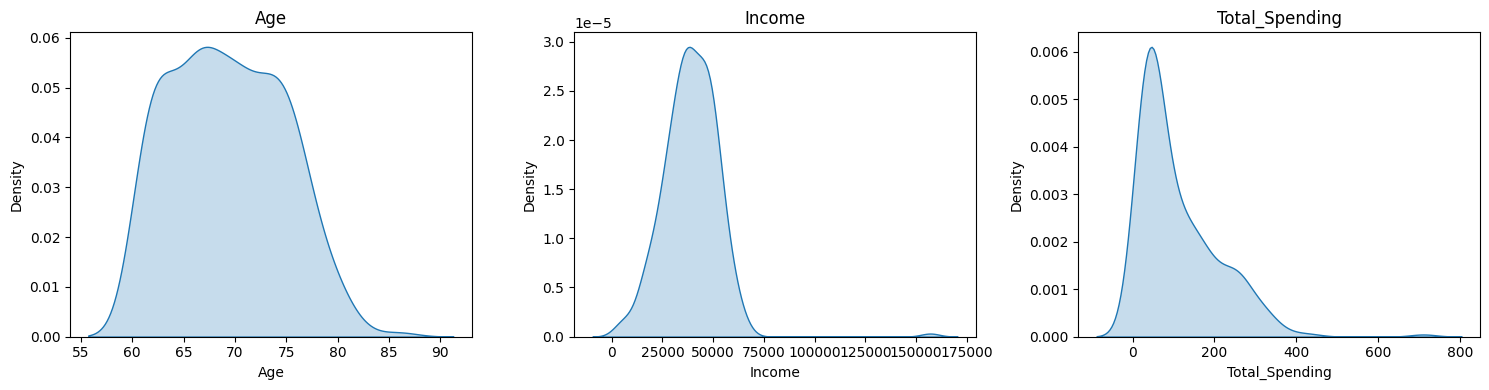

In [145]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
for i,feature in enumerate(['Age', 'Income', 'Total_Spending']):
    sns.kdeplot(Cluster3_2[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

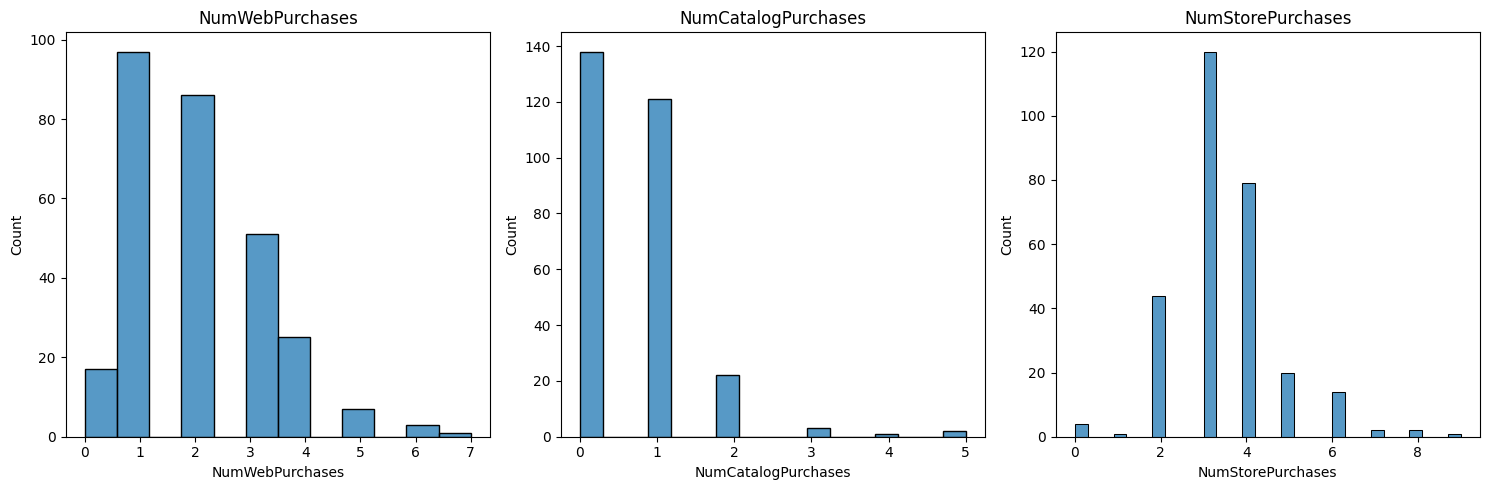

In [146]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_2[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

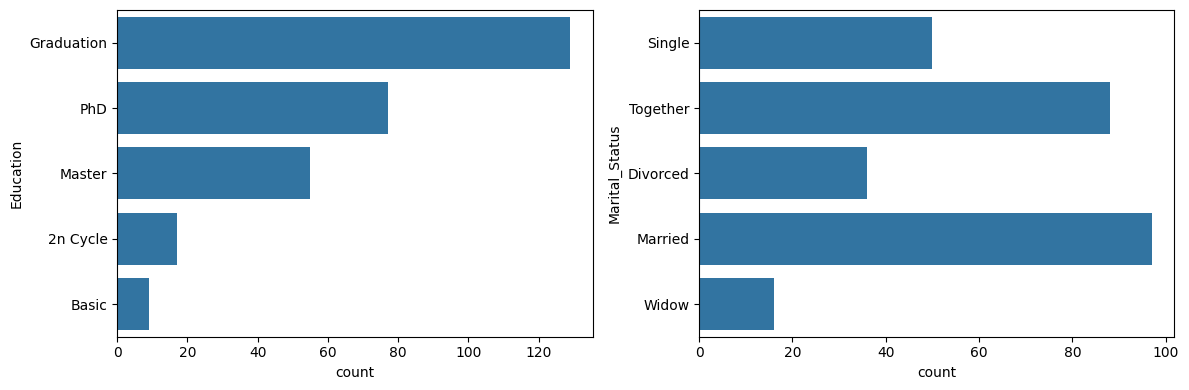

In [147]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_2['Education'], ax=ax[0])
sns.countplot(Cluster3_2['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()

## Cluster: Older-Aged, Higher-Income, Higher-Spending 

**Age:** Ranges from 61 to 85. exclusively older customers, similar range to the other senior cluster. Mean (69.62) and median (70) are close, with mode at 61. The KDE shows density concentrated around 63-78, with a gentle secondary bump near 65-68, tapering off gradually toward the mid-80s.

**Income:** Ranges from 22,507 to 113,734. Mean (66,523.92) and median (65,846) are close, indicating a reasonably symmetric distribution. This is a **moderately affluent segment** notably higher income than the other senior cluster (median ~38,823), making this a clearly distinct older-customer profile.

**Total Spending:** Mean (1,010.37) and median (976) are close (mode also near 976), indicating a fairly symmetric, well-behaved distribution. This is a **high-spending segment** and far above the other senior cluster's median of 70. The KDE shows a broad shape with peaks around 500-600 and 1,000-1,100, suggesting some internal variation in spending levels, similar to patterns seen in other high-spending clusters.

**Purchase Behavior:**
- **Web Purchases:** Range 1-27. Most customers made 4-8 purchases, peaking around 5-6. A small tail extends to 27 (likely a residual outlier). Web is an actively used channel for this group.
- **Catalog Purchases:** Range 0-11. Most customers made 2-6 purchases, peaking around 2, with a gradual decline through 10-11. A meaningfully engaged secondary channel, unlike the low-spending senior cluster.
- **Store Purchases:** Range 0-13. Peak clearly at 6 (~130), with mean (7.88) and median (8) sitting close to that peak. A smaller secondary bump appears around 12, hinting at a subgroup of frequent in-store shoppers. Store is the strongest channel for this group.

**Education:** Graduation dominates (~275), followed by PhD (~140) and Master (~105). PhD again outranks Master, consistent with your other clusters. 2n Cycle (~40) is a smaller minority.

**Marital Status:** Married (~205) is the largest group, followed by Together (~150) and Single (~100). Widow (~38) is meaningfully present, consistent with this being an older segment. Divorced (~65) is a smaller minority.

In [148]:
cluster_summary(Cluster3_3, features)

,features,min,max,diff,mean,median,mode
0,Age,61.0,85.0,24.0,69.62,70.0,61.0
1,Income,22507.0,113734.0,91227.0,66523.92,65846.0,83844.0
2,Total_Spending,227.0,2440.0,2213.0,1010.37,976.0,976.0
3,NumWebPurchases,1.0,27.0,26.0,5.82,6.0,6.0
4,NumCatalogPurchases,0.0,11.0,11.0,4.52,4.0,2.0
5,NumStorePurchases,0.0,13.0,13.0,7.88,8.0,5.0


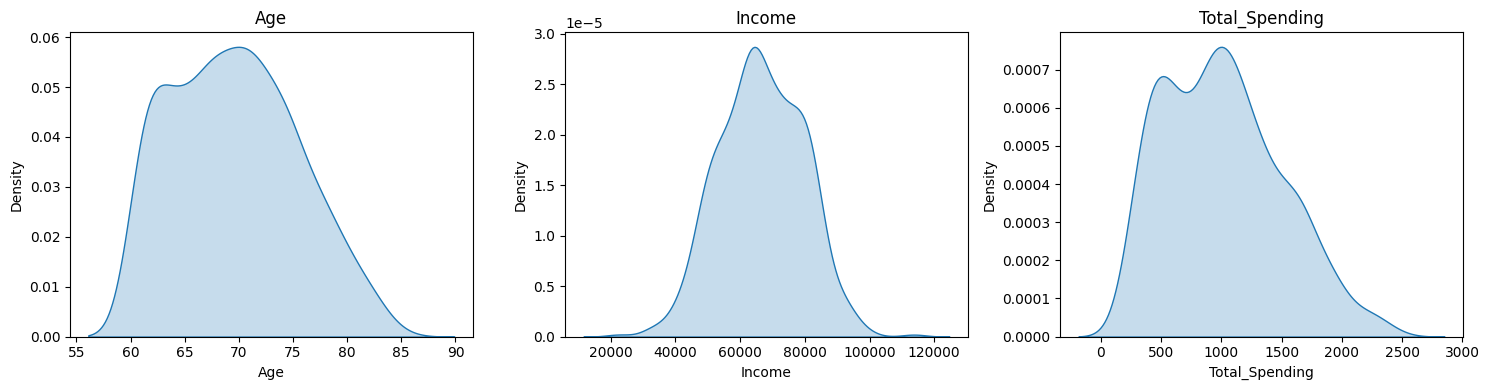

In [149]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
for i,feature in enumerate(['Age', 'Income', 'Total_Spending']):
    sns.kdeplot(Cluster3_3[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

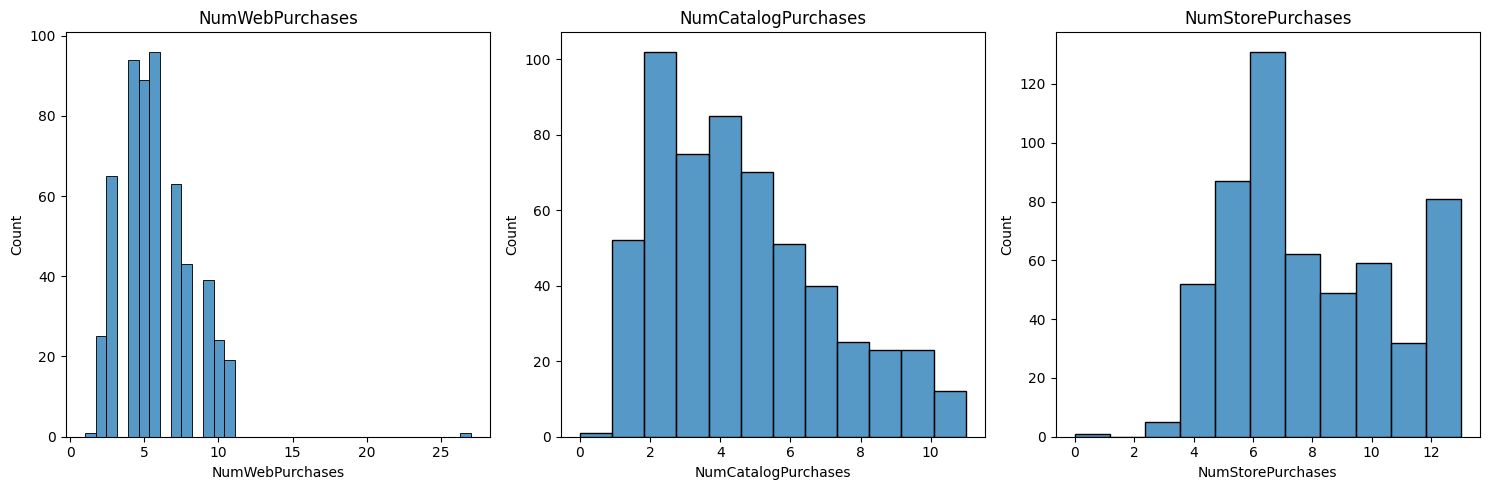

In [150]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_3[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

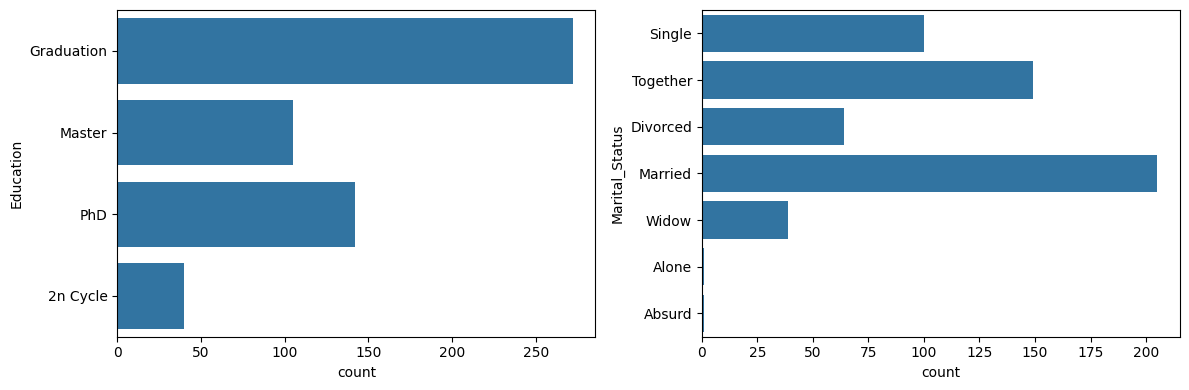

In [151]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_3['Education'], ax=ax[0])
sns.countplot(Cluster3_3['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()